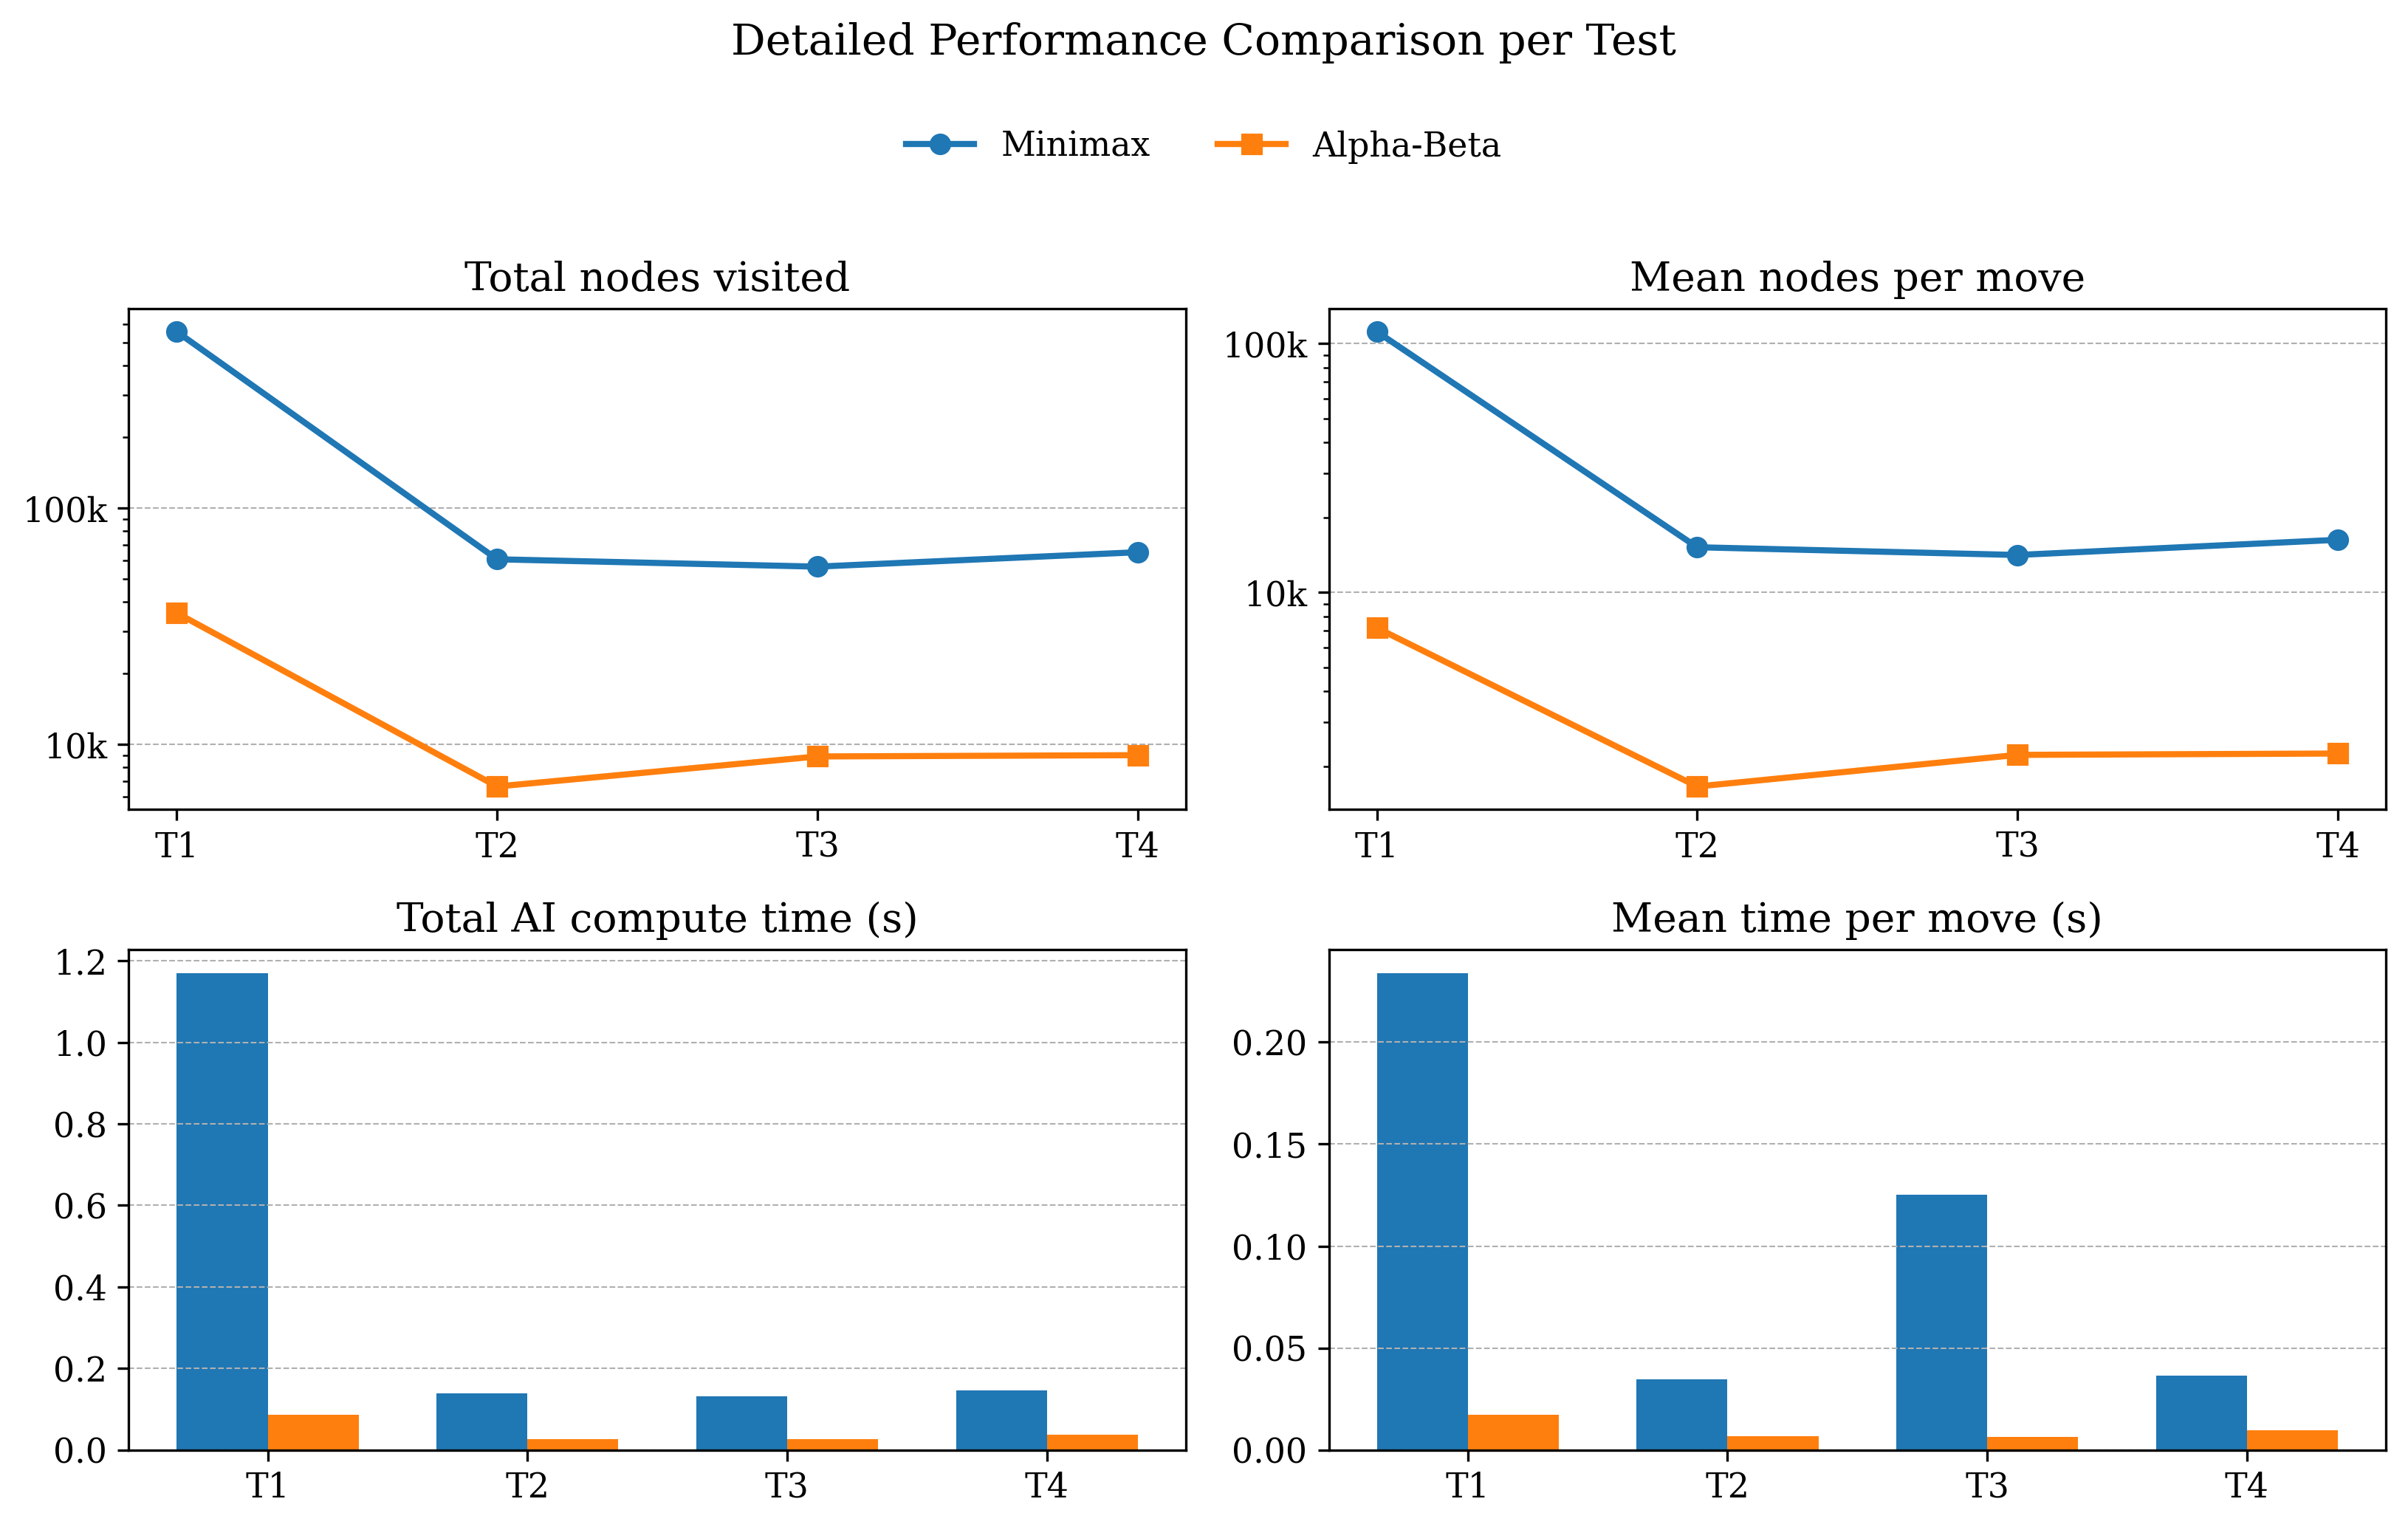

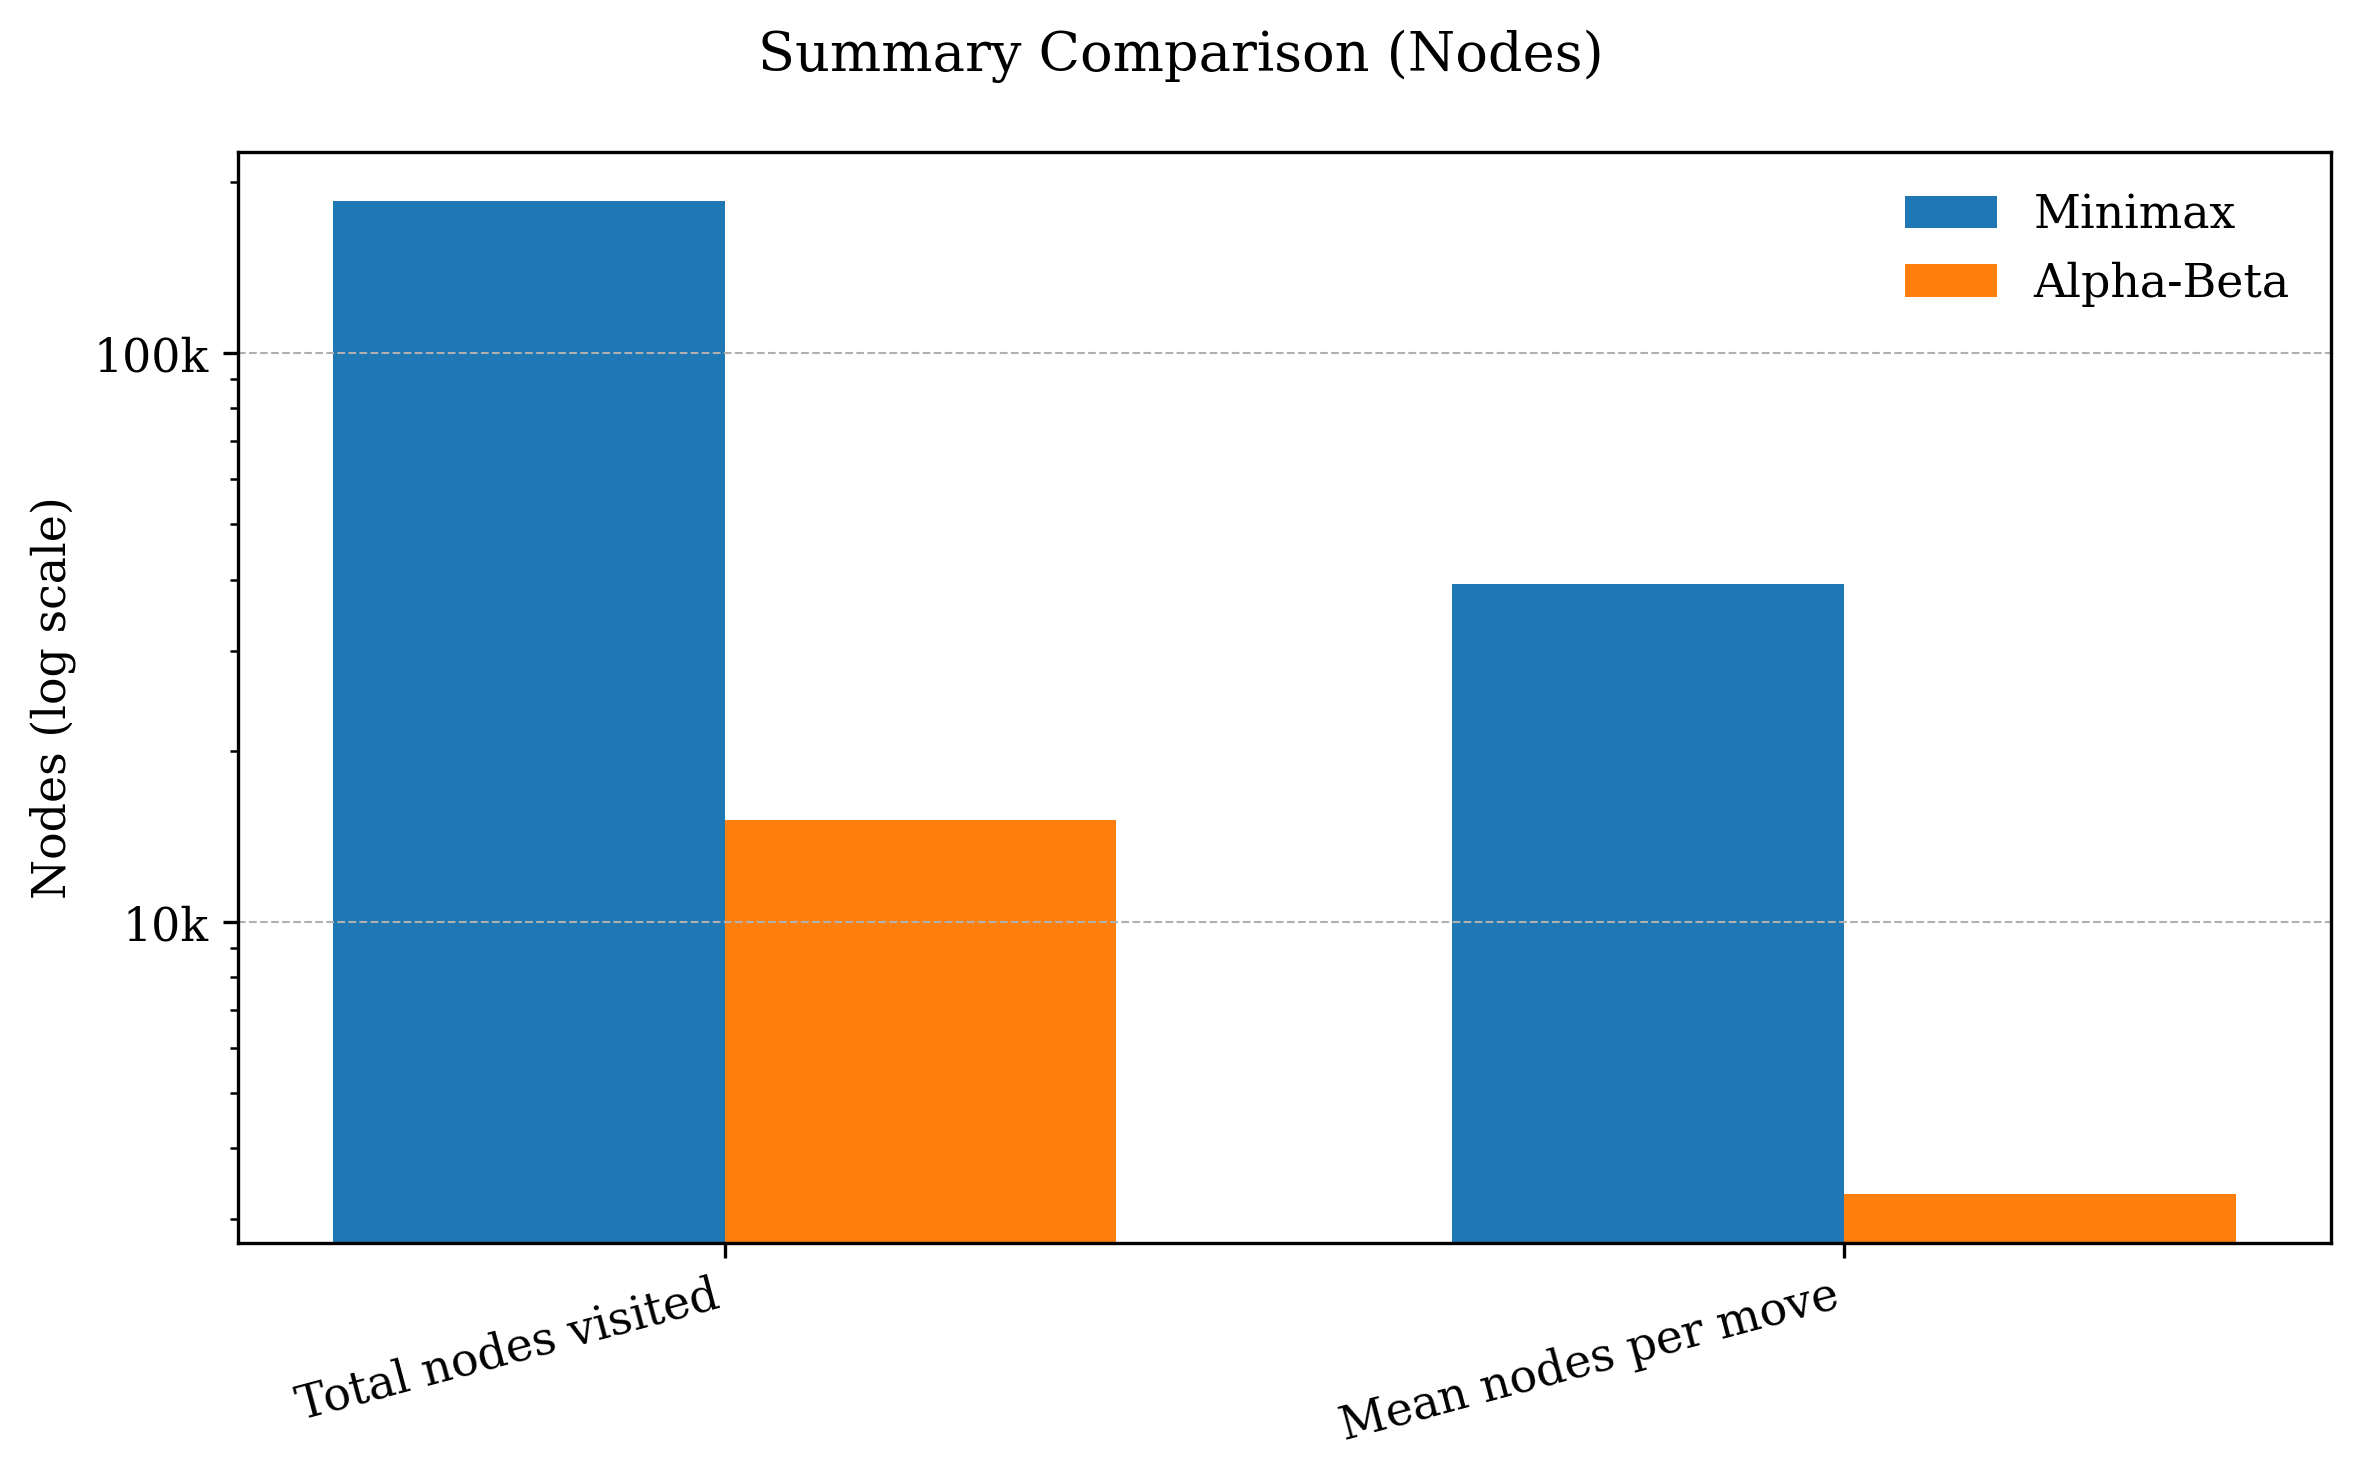

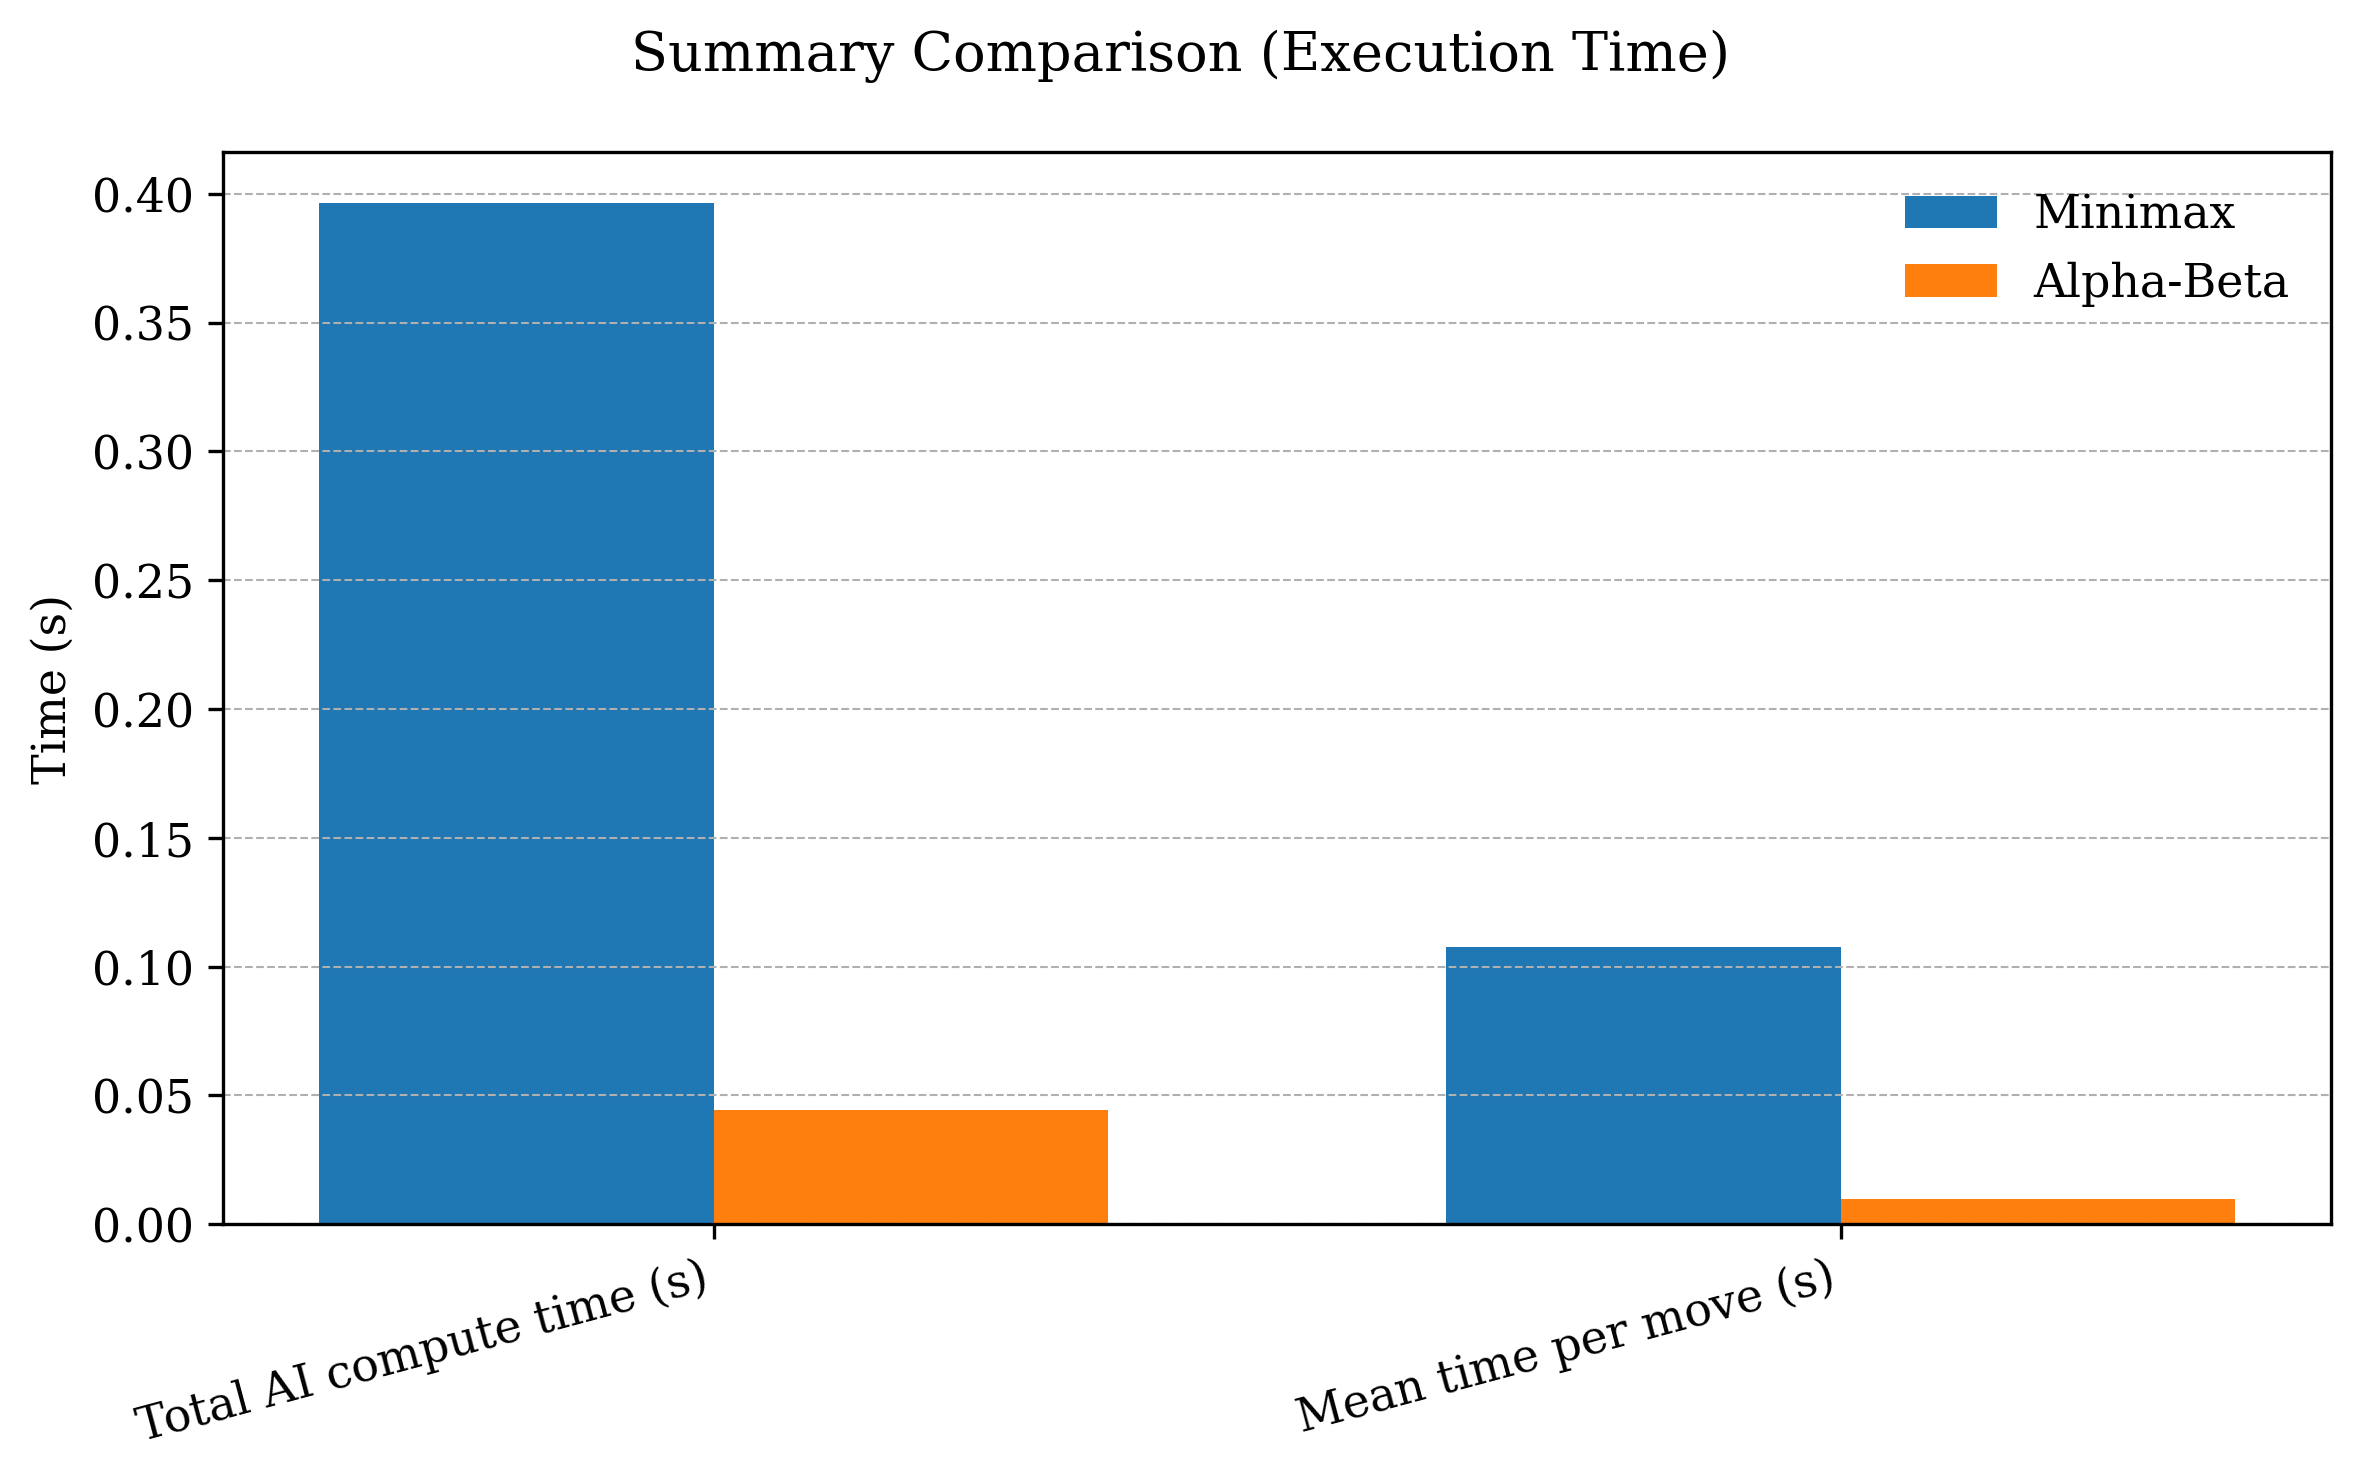

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
from google.colab import files

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "figure.dpi": 300
})

# 👉 Formato compacto (k, M)
def human_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}k'
    else:
        return f'{x:.0f}'

# =========================
# Tabla 1: resultados por test
# =========================

tests = ["T1", "T2", "T3", "T4"]

data = {
    "Metric": [
        "Total nodes visited", "Total nodes visited",
        "Mean nodes per move", "Mean nodes per move",
        "Total AI compute time (s)", "Total AI compute time (s)",
        "Mean time per move (s)", "Mean time per move (s)"
    ],
    "Algorithm": [
        "Minimax", "Alpha-Beta",
        "Minimax", "Alpha-Beta",
        "Minimax", "Alpha-Beta",
        "Minimax", "Alpha-Beta"
    ],
    "T1": [557487, 35943, 111497, 7188, 1.1687, 0.0868, 0.2337, 0.0174],
    "T2": [60688, 6628, 15172, 1657, 0.1385, 0.0264, 0.0346, 0.0066],
    "T3": [56490, 8882, 14122, 2220, 0.1321, 0.0259, 0.1251, 0.0065],
    "T4": [65014, 8994, 16253, 2248, 0.1465, 0.0380, 0.0366, 0.0095],
}

df = pd.DataFrame(data)
metrics = df["Metric"].unique()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

bar_width = 0.35
x = np.arange(len(tests))

for ax, metric in zip(axes, metrics):
    subset = df[df["Metric"] == metric]

    minimax = subset[subset["Algorithm"] == "Minimax"][tests].values.flatten()
    alpha_beta = subset[subset["Algorithm"] == "Alpha-Beta"][tests].values.flatten()

    if metric in ["Total nodes visited", "Mean nodes per move"]:
        ax.plot(x, minimax, marker="o", linewidth=2, label="Minimax")
        ax.plot(x, alpha_beta, marker="s", linewidth=2, label="Alpha-Beta")

        # 👉 Escala log + formato compacto
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(FuncFormatter(human_format))
    else:
        ax.bar(x - bar_width / 2, minimax, bar_width, label="Minimax")
        ax.bar(x + bar_width / 2, alpha_beta, bar_width, label="Alpha-Beta")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(tests)
    ax.grid(axis="y", linestyle="--", linewidth=0.5)

# 👉 Leyenda global
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=2,
           frameon=False,
           bbox_to_anchor=(0.5, 0.93))

fig.suptitle("Detailed Performance Comparison per Test", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.90])

fig.savefig("detailed_results_per_test.png", bbox_inches="tight")

plt.show()


# =========================
# Summary: SOLO NODOS
# =========================

summary_nodes = pd.DataFrame({
    "Metric": [
        "Total nodes visited",
        "Mean nodes per move"
    ],
    "Minimax Mean": [184919, 39261],
    "Alpha-Beta Mean": [15111, 3328],
})

x = np.arange(len(summary_nodes))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - bar_width / 2, summary_nodes["Minimax Mean"], bar_width, label="Minimax")
ax.bar(x + bar_width / 2, summary_nodes["Alpha-Beta Mean"], bar_width, label="Alpha-Beta")

ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(human_format))

ax.set_ylabel("Nodes (log scale)")
ax.set_xticks(x)
ax.set_xticklabels(summary_nodes["Metric"], rotation=15, ha="right")
ax.grid(axis="y", linestyle="--", linewidth=0.5)

ax.legend(frameon=False)

fig.suptitle("Summary Comparison (Nodes)", fontsize=13)
fig.tight_layout()

fig.savefig("summary_nodes.png", bbox_inches="tight")
plt.show()

# =========================
# Summary: SOLO TIEMPOS
# =========================

summary_time = pd.DataFrame({
    "Metric": [
        "Total AI compute time (s)",
        "Mean time per move (s)"
    ],
    "Minimax Mean": [0.3965, 0.1075],
    "Alpha-Beta Mean": [0.0443, 0.0100],
})

x = np.arange(len(summary_time))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - bar_width / 2, summary_time["Minimax Mean"], bar_width, label="Minimax")
ax.bar(x + bar_width / 2, summary_time["Alpha-Beta Mean"], bar_width, label="Alpha-Beta")

ax.set_ylabel("Time (s)")
ax.set_xticks(x)
ax.set_xticklabels(summary_time["Metric"], rotation=15, ha="right")
ax.grid(axis="y", linestyle="--", linewidth=0.5)

ax.legend(frameon=False)

fig.suptitle("Summary Comparison (Execution Time)", fontsize=13)
fig.tight_layout()

fig.savefig("summary_time.png", bbox_inches="tight")
plt.show()


# =========================
# Descargar
# =========================

files.download("detailed_results_per_test.png")
files.download("summary_nodes.png")
files.download("summary_time.png")